# Criteo click prediction

Predict the probability that a user clicks on an ad, using a sample of the Criteo 1TB Click Logs dataset.

train: 2015-02-15 and 2015-02-16
validation: 2015-02-17
test: 2015-02-18

Data downloaded with `scripts/download_data.py`.

In [1]:
# part 1 : imports

import glob

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [2]:
# part 2 : load data

def load(pattern):
    files = sorted(glob.glob(pattern))
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)


train = load("../data/raw/data/day=2015-02-15/*.parquet")
train = pd.concat([train, load("../data/raw/data/day=2015-02-16/*.parquet")], ignore_index=True)
val = load("../data/raw/data/day=2015-02-17/*.parquet")
test = load("../data/raw/data/day=2015-02-18/*.parquet")

print("train:", train.shape)
print("val:  ", val.shape)
print("test: ", test.shape)

train: (2308265, 40)
val:   (769126, 40)
test:  (706671, 40)


In [3]:
num_cols = [f"integer_feature_{i}" for i in range(1, 14)]
cat_cols = [f"categorical_feature_{i}" for i in range(1, 27)]

train.head()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,NaN,84.0,NaN,31.0,12.0,0.0,0.0,1,8,...,NaN,f7389918,139221a3,8024f45f,0683bc6f,fa7eca6c,NaN,e716200f,30436bfc,2ccea557
1,0,104.0,1045.0,30.0,NaN,1.0,0.0,0.0,1,9,...,d20856aa,6785af47,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,c91256e2,30436bfc,e1be5ef2
2,0,6.0,145.0,10.0,NaN,4.0,0.0,0.0,0,12,...,NaN,a1eb1511,9512c20b,ef426d46,0683bc6f,6e86ac23,NaN,af97a0c1,30436bfc,b757e957
3,0,40.0,360.0,7.0,NaN,9.0,0.0,0.0,312,0,...,d20856aa,b8170bba,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,245d9da7,30436bfc,e1be5ef2
4,0,NaN,339.0,NaN,NaN,1.0,0.0,0.0,248,7,...,NaN,7232d217,9512c20b,14cde947,45f35b4b,f52bfc8b,NaN,edc6442f,ff654802,2ccea557


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2308265 entries, 0 to 2308264
Data columns (total 40 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   label                   int32  
 1   integer_feature_1       float64
 2   integer_feature_2       float64
 3   integer_feature_3       float64
 4   integer_feature_4       float64
 5   integer_feature_5       float64
 6   integer_feature_6       float64
 7   integer_feature_7       float64
 8   integer_feature_8       int32  
 9   integer_feature_9       int32  
 10  integer_feature_10      float64
 11  integer_feature_11      float64
 12  integer_feature_12      float64
 13  integer_feature_13      float64
 14  categorical_feature_1   str    
 15  categorical_feature_2   str    
 16  categorical_feature_3   str    
 17  categorical_feature_4   str    
 18  categorical_feature_5   str    
 19  categorical_feature_6   str    
 20  categorical_feature_7   str    
 21  categorical_feature_8   str    
 22  categ

## Data exploration

label
0    2234418
1      73847
Name: count, dtype: int64
click rate: 3.2 %


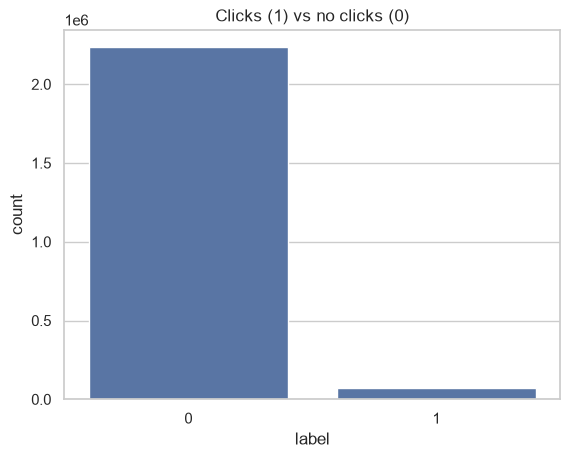

In [5]:
# part 3 : target

print(train["label"].value_counts())
print("click rate:", round(train["label"].mean() * 100, 2), "%")

sns.countplot(x="label", data=train)
plt.title("Clicks (1) vs no clicks (0)")
plt.show()

Only ~3% of the ads are clicked, so the data is very imbalanced. Accuracy is not a good metric here (predicting "no click" everywhere gives 97%), so the models are evaluated with **log loss** and **ROC AUC**.

integer_feature_5         41.5
integer_feature_11        41.5
integer_feature_4         35.5
categorical_feature_17    34.3
categorical_feature_23    34.3
categorical_feature_14    34.3
categorical_feature_16    34.3
integer_feature_13        24.2
integer_feature_3         24.2
integer_feature_1         18.6
integer_feature_2          9.8
integer_feature_6          8.5
integer_feature_10         8.5
categorical_feature_11     3.9
categorical_feature_1      3.9
categorical_feature_22     3.9
categorical_feature_21     3.9
categorical_feature_20     3.9
categorical_feature_10     3.9
integer_feature_7          3.0
integer_feature_12         2.2
dtype: float64


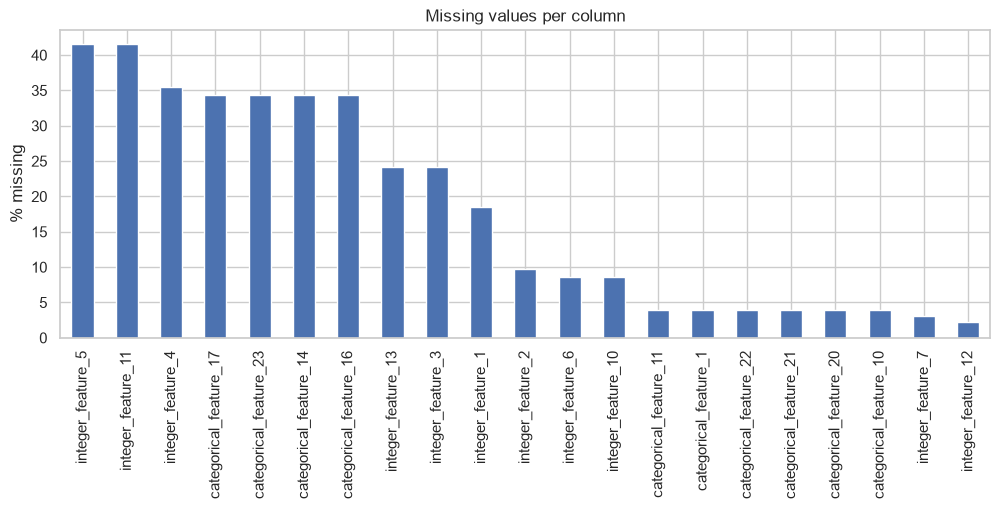

In [6]:
# part 4 : missing values

missing = train.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(missing.round(1))

missing.plot.bar(figsize=(12, 4))
plt.ylabel("% missing")
plt.title("Missing values per column")
plt.show()

Many columns have missing values (up to 41%). They are simply filled with 0 during preprocessing.

In [7]:
# part 5 : numerical features

train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
integer_feature_1,1879954.0,36.160099,494.349148,1.0,3.0,8.0,23.0,65535.0
integer_feature_2,2082936.0,432.690011,710.269597,1.0,61.0,196.0,514.0,8000.0
integer_feature_3,1749991.0,7.238196,10.780944,0.0,2.0,4.0,9.0,3480.0
integer_feature_4,1487816.0,134.463432,692.472907,0.0,10.0,34.0,100.0,244016.0
integer_feature_5,1350418.0,21.750927,74.589806,1.0,2.0,6.0,16.0,5115.0
integer_feature_6,2111193.0,1.576453,6.660422,0.0,0.0,0.0,1.0,943.0
integer_feature_7,2238379.0,0.159161,2.133005,0.0,0.0,0.0,0.0,983.0
integer_feature_8,2308265.0,112.749743,386.868048,-1.0,1.0,5.0,50.0,21095.0
integer_feature_9,2308265.0,9.837399,18.355113,0.0,1.0,5.0,14.0,14019.0
integer_feature_10,2111193.0,0.281129,0.552274,0.0,0.0,0.0,0.0,9.0


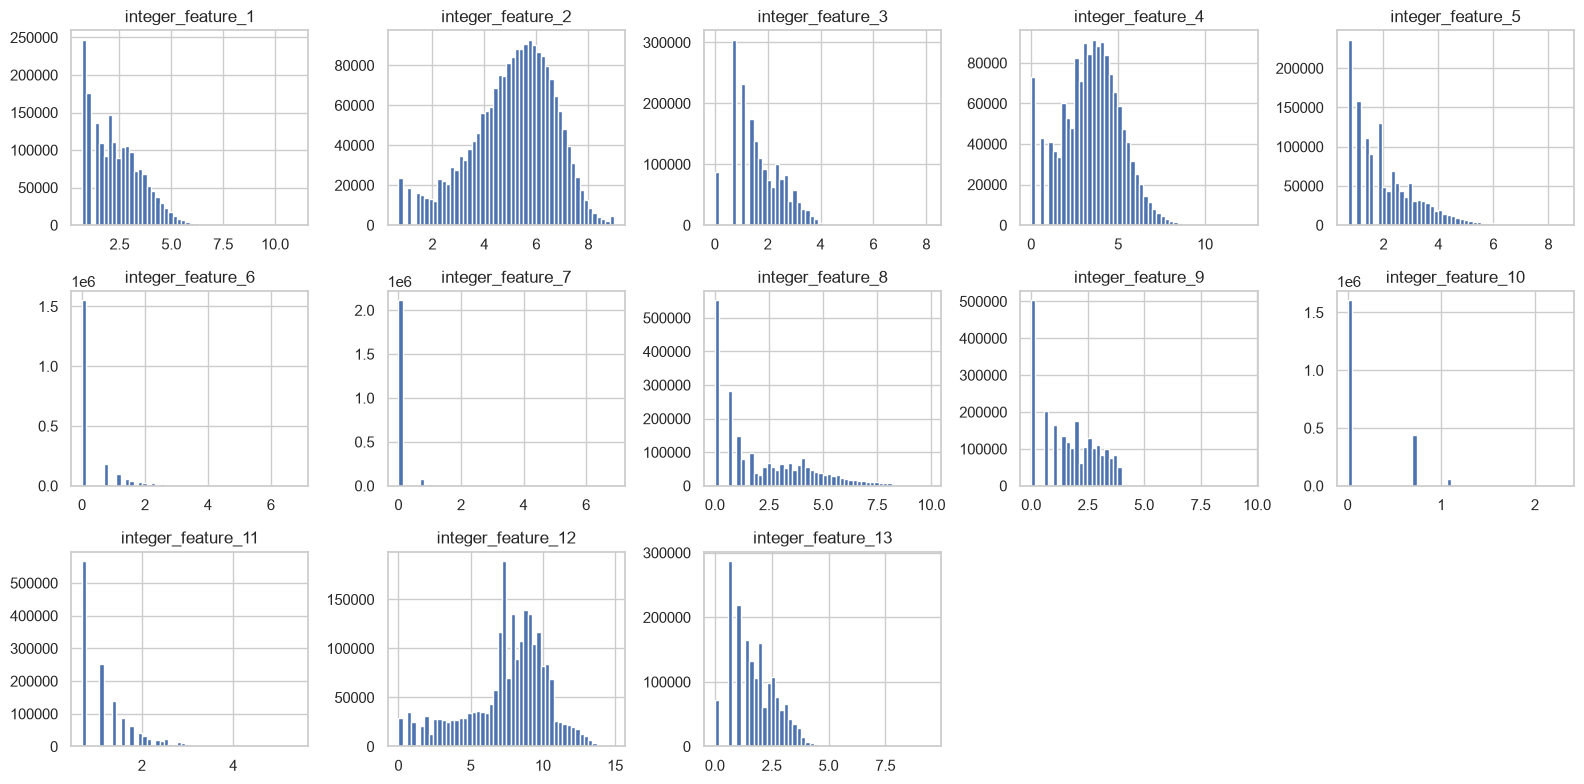

In [8]:
# the integer features are counts with very long tails, so they are easier to look at with log(1 + x)
fig, axes = plt.subplots(3, 5, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(np.log1p(train[col].dropna().clip(lower=0)), bins=50)
    ax.set_title(col)
axes.flat[-1].axis("off")
axes.flat[-2].axis("off")
plt.tight_layout()
plt.show()

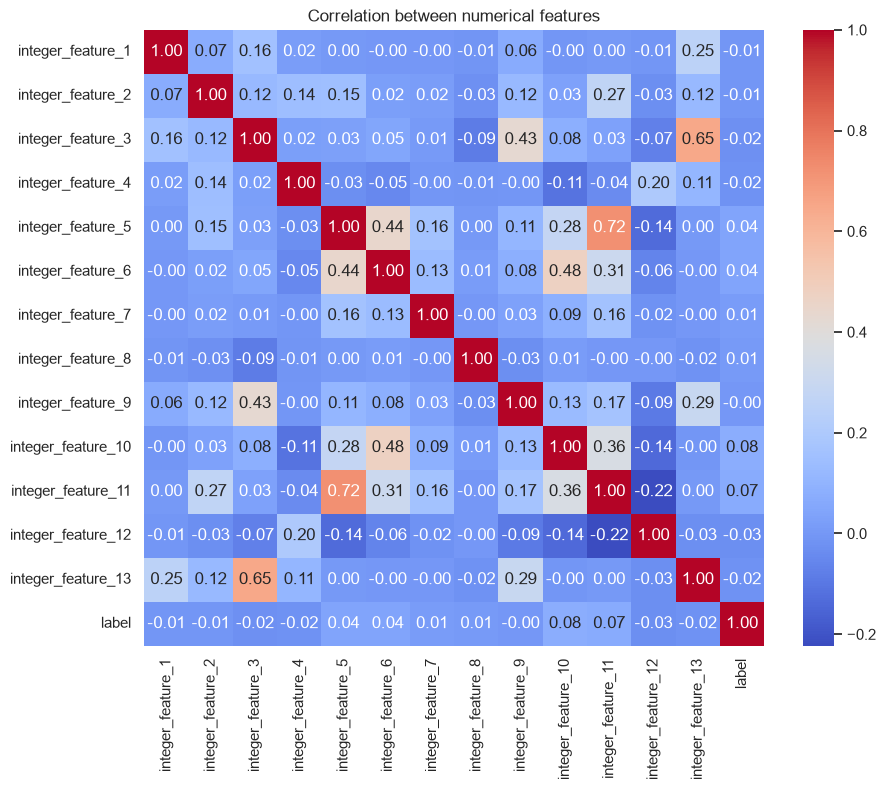

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[num_cols + ["label"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between numerical features")
plt.show()

categorical_feature_20    543367
categorical_feature_1     499265
categorical_feature_22    455601
categorical_feature_10    374717
categorical_feature_21    211807
categorical_feature_11     77781
categorical_feature_12     66565
categorical_feature_23     60755
categorical_feature_5      18689
categorical_feature_2      18351
categorical_feature_3      14213
categorical_feature_24      9197
categorical_feature_15      7338
categorical_feature_4       6926
categorical_feature_7       6424
categorical_feature_14      2084
categorical_feature_8       1237
categorical_feature_18       923
categorical_feature_25        65
categorical_feature_16        59
categorical_feature_9         48
categorical_feature_26        33
categorical_feature_19        14
categorical_feature_13        10
categorical_feature_17         3
categorical_feature_6          3
dtype: int64


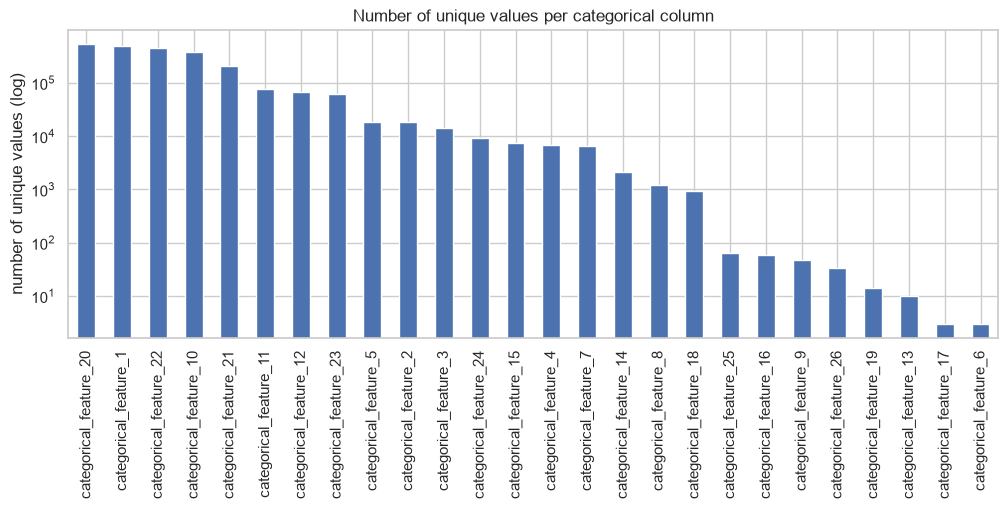

In [10]:
# part 6 : categorical features

n_unique = train[cat_cols].nunique().sort_values(ascending=False)
print(n_unique)

n_unique.plot.bar(figsize=(12, 4), logy=True)
plt.ylabel("number of unique values (log)")
plt.title("Number of unique values per categorical column")
plt.show()

Some categorical columns have hundreds of thousands of different values, so one-hot encoding is not possible. Instead each value is replaced by **how many times it appears in the training data** (frequency encoding). Values never seen in training get 0.

## Preprocessing

In [11]:
# part 7 : preprocessing

# value counts are computed on the train set only, and reused for val and test
counts = {col: train[col].value_counts() for col in cat_cols}


def preprocess(df):
    X = pd.DataFrame(index=df.index)
    for col in num_cols:
        X[col] = np.log1p(df[col].fillna(0).clip(lower=0))
    for col in cat_cols:
        X[col] = df[col].map(counts[col]).fillna(0)
    return X


X_train, y_train = preprocess(train), train["label"]
X_val, y_val = preprocess(val), val["label"]
X_test, y_test = preprocess(test), test["label"]

X_train.head()

,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,integer_feature_10,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0.000000,4.442651,0.000000,3.465736,2.564949,0.0,0.0,0.693147,2.197225,0.0,...,0.0,15611,141271,12309.0,45274.0,12309.0,0.0,4485,954729,390098
1,4.653960,6.952729,3.433987,0.000000,0.693147,0.0,0.0,0.693147,2.302585,0.0,...,944377.0,17087,540309,540318.0,540318.0,540318.0,540309.0,758,954729,526642
2,1.945910,4.983607,2.397895,0.000000,1.609438,0.0,0.0,0.000000,2.564949,0.0,...,0.0,386544,1197202,13222.0,45274.0,13222.0,0.0,463,954729,707616
3,3.713572,5.888878,2.079442,0.000000,2.302585,0.0,0.0,5.746203,0.000000,0.0,...,944377.0,1153367,540309,540318.0,540318.0,540318.0,540309.0,2403,954729,526642
4,0.000000,5.828946,0.000000,0.000000,0.693147,0.0,0.0,5.517453,2.079442,0.0,...,0.0,190819,1197202,1.0,1.0,1.0,0.0,30,526435,390098


## Models

In [12]:
# part 8 : baseline = always predict the average click rate

baseline_pred = np.full(len(y_val), y_train.mean())
print("baseline log loss:", round(log_loss(y_val, baseline_pred), 4))

baseline log loss: 0.1426


In [13]:
# part 9 : logistic regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

logreg_pred = logreg.predict_proba(X_val_scaled)[:, 1]
print("log loss:", round(log_loss(y_val, logreg_pred), 4))
print("ROC AUC: ", round(roc_auc_score(y_val, logreg_pred), 4))

log loss: 0.1341
ROC AUC:  0.702


In [14]:
# part 10 : LightGBM

lgbm = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, num_leaves=63, verbose=-1)
lgbm.fit(
    X_train, y_train,
    eval_X=X_val, eval_y=y_val,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

lgbm_pred = lgbm.predict_proba(X_val)[:, 1]
print("log loss:", round(log_loss(y_val, lgbm_pred), 4))
print("ROC AUC: ", round(roc_auc_score(y_val, lgbm_pred), 4))

Training until validation scores don't improve for 50 rounds


[100]	valid_0's binary_logloss: 0.129764


[200]	valid_0's binary_logloss: 0.128784


[300]	valid_0's binary_logloss: 0.128579


[400]	valid_0's binary_logloss: 0.128497


[500]	valid_0's binary_logloss: 0.128429


Early stopping, best iteration is:
[523]	valid_0's binary_logloss: 0.128412


log loss: 0.1284
ROC AUC:  0.7503


## Results

In [15]:
# part 11 : compare the models on the validation set

results = pd.DataFrame({
    "model": ["baseline", "logistic regression", "LightGBM"],
    "log_loss": [log_loss(y_val, p) for p in (baseline_pred, logreg_pred, lgbm_pred)],
    "roc_auc": [0.5, roc_auc_score(y_val, logreg_pred), roc_auc_score(y_val, lgbm_pred)],
})
results

,model,log_loss,roc_auc
0,baseline,0.142567,0.500000
1,logistic regression,0.134065,0.701982
2,LightGBM,0.128412,0.750302


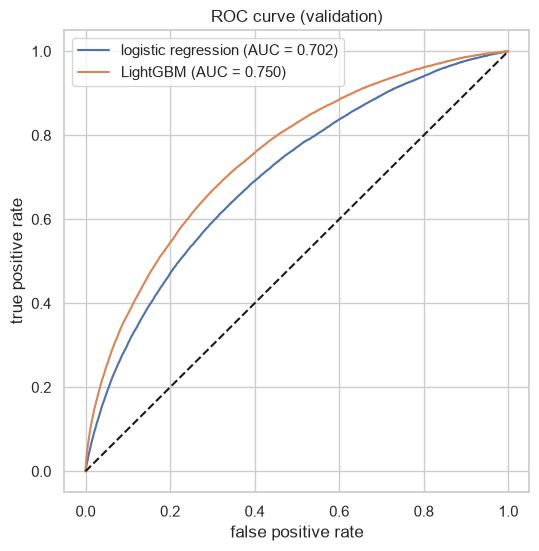

In [16]:
plt.figure(figsize=(6, 6))
for name, pred in [("logistic regression", logreg_pred), ("LightGBM", lgbm_pred)]:
    fpr, tpr, _ = roc_curve(y_val, pred)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_val, pred):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve (validation)")
plt.legend()
plt.show()

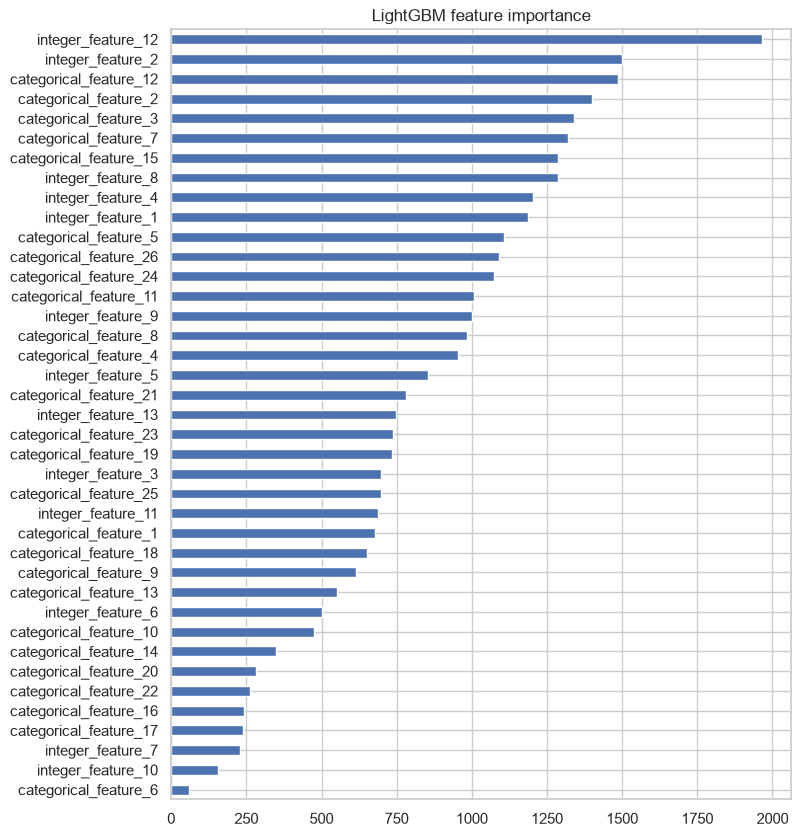

In [17]:
# part 12 : feature importance

importance = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values()
importance.plot.barh(figsize=(8, 10))
plt.title("LightGBM feature importance")
plt.show()

In [18]:
# part 13 : final score of the best model on the test set (not used before)

test_pred = lgbm.predict_proba(X_test)[:, 1]
test_baseline = log_loss(y_test, np.full(len(y_test), y_train.mean()))

print("test log loss:", round(log_loss(y_test, test_pred), 4), " (baseline:", round(test_baseline, 4), ")")
print("test ROC AUC: ", round(roc_auc_score(y_test, test_pred), 4))

test log loss: 0.127  (baseline: 0.1406 )
test ROC AUC:  0.7484


## Transformer (test)

A small transformer for tabular data: every feature becomes a vector (an *embedding*), and the transformer's attention layers learn how the features interact with each other.

- categorical columns: each value gets an id (values seen fewer than 10 times in train, or never seen, get id 0) → `nn.Embedding`
- numerical columns: `log1p` + standardisation, then each one is turned into a vector with its own weights

In [19]:
# part 14 : transformer - data preparation

import torch
import torch.nn as nn

# on macOS, LightGBM and PyTorch each load their own copy of OpenMP and their threads can block each other
# (training never finishes). The heavy work runs on the GPU, so one CPU thread for PyTorch is enough.
torch.set_num_threads(1)

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

# one id per categorical value (ids start at 1, 0 = rare or unknown value)
vocab = {}
for col in cat_cols:
    vc = train[col].value_counts()
    vc = vc[vc >= 10]
    vocab[col] = {value: i + 1 for i, value in enumerate(vc.index)}


def encode(df):
    cats = np.stack([df[col].map(vocab[col]).fillna(0).astype("int64").values for col in cat_cols], axis=1)
    nums = np.log1p(df[num_cols].fillna(0).clip(lower=0)).values.astype("float32")
    return cats, nums


cats_train, nums_train = encode(train)
cats_val, nums_val = encode(val)
cats_test, nums_test = encode(test)

mean, std = nums_train.mean(axis=0), nums_train.std(axis=0)
nums_train = (nums_train - mean) / std
nums_val = (nums_val - mean) / std
nums_test = (nums_test - mean) / std

print("vocabulary size per column:", [len(vocab[col]) for col in cat_cols])

device: mps


vocabulary size per column: [9850, 8028, 10777, 4176, 10344, 3, 5841, 1089, 30, 11331, 9603, 15784, 9, 1476, 4088, 51, 3, 643, 14, 9541, 12107, 10369, 8540, 7147, 43, 33]


In [20]:
# part 15 : transformer - model

class TabTransformer(nn.Module):
    def __init__(self, vocab_sizes, n_num, d=16):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(n, d) for n in vocab_sizes])
        self.num_weight = nn.Parameter(torch.randn(n_num, d) * 0.1)
        self.num_bias = nn.Parameter(torch.zeros(n_num, d))
        layer = nn.TransformerEncoderLayer(d_model=d, nhead=2, dim_feedforward=64, dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.head = nn.Linear(d * (len(vocab_sizes) + n_num), 1)

    def forward(self, cats, nums):
        cat_tokens = torch.stack([emb(cats[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        num_tokens = nums.unsqueeze(-1) * self.num_weight + self.num_bias
        x = torch.cat([cat_tokens, num_tokens], dim=1)  # (batch, 39 features, d)
        x = self.encoder(x)
        return self.head(x.flatten(1)).squeeze(-1)  # one logit per row


transformer = TabTransformer([len(vocab[col]) + 1 for col in cat_cols], len(num_cols)).to(device)
print("parameters:", sum(p.numel() for p in transformer.parameters()))

parameters: 2262737


In [21]:
# part 16 : transformer - training

# train on the full training set (2.3M rows)
cats_train_t = torch.tensor(cats_train)
nums_train_t = torch.tensor(nums_train)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)


def predict(model, cats, nums, batch_size=16384):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(cats), batch_size):
            c = torch.tensor(cats[i:i + batch_size]).to(device)
            n = torch.tensor(nums[i:i + batch_size]).to(device)
            preds.append(torch.sigmoid(model(c, n)).cpu())
    return torch.cat(preds).numpy()


optimizer = torch.optim.Adam(transformer.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()
batch_size = 4096
best_loss, best_state = 1.0, None

torch.manual_seed(42)
for epoch in range(3):
    transformer.train()
    perm = torch.randperm(len(y_train_t))
    for i in range(0, len(perm), batch_size):
        idx = perm[i:i + batch_size]
        logits = transformer(cats_train_t[idx].to(device), nums_train_t[idx].to(device))
        loss = loss_fn(logits, y_train_t[idx].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    val_pred = predict(transformer, cats_val, nums_val)
    val_loss = log_loss(y_val, val_pred)
    print(f"epoch {epoch + 1}: val log loss {val_loss:.4f}, val ROC AUC {roc_auc_score(y_val, val_pred):.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k: v.clone() for k, v in transformer.state_dict().items()}

transformer.load_state_dict(best_state)

epoch 1: val log loss 0.1321, val ROC AUC 0.7238


epoch 2: val log loss 0.1299, val ROC AUC 0.7380


epoch 3: val log loss 0.1303, val ROC AUC 0.7445


<All keys matched successfully>

In [22]:
# part 17 : compare all models

transformer_pred = predict(transformer, cats_val, nums_val)

results = pd.DataFrame({
    "model": ["baseline", "logistic regression", "LightGBM", "transformer"],
    "log_loss": [log_loss(y_val, p) for p in (baseline_pred, logreg_pred, lgbm_pred, transformer_pred)],
    "roc_auc": [0.5] + [roc_auc_score(y_val, p) for p in (logreg_pred, lgbm_pred, transformer_pred)],
})
results

,model,log_loss,roc_auc
0,baseline,0.142567,0.500000
1,logistic regression,0.134065,0.701982
2,LightGBM,0.128412,0.750302
3,transformer,0.129931,0.737953


In [23]:
transformer_test_pred = predict(transformer, cats_test, nums_test)
print("transformer test log loss:", round(log_loss(y_test, transformer_test_pred), 4))
print("transformer test ROC AUC: ", round(roc_auc_score(y_test, transformer_test_pred), 4))

transformer test log loss: 0.1285
transformer test ROC AUC:  0.7358


## Save the models

The API needs the trained models **and** what was used to prepare the data (value counts, vocabulary, mean/std), so that new requests are transformed exactly like the training data.

In [24]:
# part 18 : save the models

import os

import joblib

os.makedirs("../models", exist_ok=True)

# LightGBM + the value counts used to encode the categorical columns
joblib.dump({"model": lgbm, "counts": counts}, "../models/lightgbm.joblib")

# transformer: weights (moved to cpu so they can be loaded without a GPU) + what is needed to prepare the input
torch.save({
    "state_dict": {k: v.cpu() for k, v in transformer.state_dict().items()},
    "vocab": vocab,
    "vocab_sizes": [len(vocab[col]) + 1 for col in cat_cols],
    "mean": mean.tolist(),
    "std": std.tolist(),
}, "../models/transformer.pt")

for f in ["../models/lightgbm.joblib", "../models/transformer.pt"]:
    print(f, round(os.path.getsize(f) / 1e6, 1), "MB")

../models/lightgbm.joblib 117.7 MB
../models/transformer.pt 12.0 MB


## Conclusion

| model | validation log loss | validation ROC AUC | test log loss | test ROC AUC |
|---|---|---|---|---|
| baseline (average click rate) | 0.1426 | 0.500 | 0.1406 | 0.500 |
| logistic regression | 0.1341 | 0.702 | | |
| **LightGBM** | **0.1284** | **0.750** | **0.1270** | **0.748** |
| transformer | 0.1299 | 0.738 | 0.1285 | 0.736 |

- **LightGBM is the best model** on both log loss and ROC AUC, and it keeps its advantage on the test day, which was never used before.
- The transformer beats the logistic regression but not LightGBM, and it takes a few minutes to train on a GPU against ~30 seconds for LightGBM. Tree models are known to be very strong on this kind of tabular data.
- The most important LightGBM features are `integer_feature_12`, `integer_feature_2` and a few categorical columns (12, 2, 3, 7).
- **LightGBM is the model served by the API** (`models/lightgbm.joblib`).